# The Bowman-2018 pipeline: single-day analysis

This notebook performs the single-day parts of the analysis pipeline that matches the Bowman+2018 results, using the python `edges-collab` stack. This loads in a full day of data, flags out bad integrations, flags RFI, and averages all retained LSTs.

In [1]:
datadir: str = "/data5/edges/data/2014_February_Boolardy/mro/low/"
alan_output_dir: str = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/"
cachedir: str = "./cache"
outputsdir: str = "/home/smurray/data4/edges/projects_with_nive/edges-bowman2018-pipeline/outputs/"

year: int = 2016
day: int = 260

do_aux_filter: bool = True
aux_filter_params: dict = {
    'minima': {},
    'maxima': {
        'adcmax': 0.35
    }
}

lst_min: float = 6.0
lst_max: float = 18.0
use_alan_coordinates: bool = True

do_power_percent_filter: bool = True
power_percent_params = {
    'min_threshold': 0.7,
    'max_threshold': 3
}

do_peak_orbcomm_filter: bool = True
peak_orbcomm_params = {
    'threshold': 40.0
}

do_maxfm_filter: bool = True
maxfm_filter_params = {
    'threshold': 200.0
}

do_rmsf_filter: bool = True
rmsf_filter_params = {
    'freq_range': [60., 80.],
    'threshold': 200.0
}

lstbin_params = {    
    "binsize": 12.0,
    'first_edge': 6.0,
    'max_edge': 18.0,
    'use_model_residuals': False,
    'in_gha': True,
}

gauss_smooth_params = {
    "size": 8,
    'decimate_at': 0,
    'maintain_flags': 1,
    'flag_threshold': 0.25,
    'use_nsamples': True,
}

do_balun_connector_loss: bool = True
do_antenna_loss: bool = False
do_ground_loss: bool = False
do_beam_correction: bool = False  # should be True to match B18      

first_freqcut_min: float = 40.0  # MHz
first_freqcut_max: float = 100.0  # MHz

inject_flags: bool = True
calfile: str = "/data4/smurray/edges/alans-pipeline/edges-cal-outputs/specal.txt"
#calfile: str = "/data4/smurray/edges/alans-pipeline/scripts/H2Case-fittpfix//specal.txt"

## Imports and Versions

In [2]:
from pathlib import Path
from importlib.metadata import version
from copy import deepcopy
import sys 

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
import pandas as pd
from pygsdata import plots, GSData, GSFlag
from pygsdata.select import select_freqs, select_lsts, lst_selector

from read_acq.gsdata import read_acq_to_gsdata, fast_lst_setter

from edges_cal import Calibrator
from edges_cal.alanmode import read_specal_as_calibrator, read_spec_txt
from edges_cal import modelling as mdl
from edges_cal.tools import dicke_calibration

from edges_analysis.calibration.calibrate import approximate_temperature, apply_beam_correction, apply_loss_correction, apply_noise_wave_calibration
from edges_analysis.calibration.loss import low2_balun_connector_loss
from edges_analysis.const import KNOWN_TELESCOPES
from edges_analysis.averaging.freqbin import gauss_smooth
from edges_analysis.averaging.lstbin import lst_bin
from edges_analysis.filters import filters
from edges_analysis.datamodel import add_model


In [3]:
print("Versions: ")
for pkg in ['read_acq', 'pygsdata', 'edges-cal', 'edges-io', 'edges-analysis']:
    print(f"{pkg:>20}: {version(pkg)}")


Versions: 
            read_acq: 1.0.3.dev17+gd442d34
            pygsdata: 0.2.1.dev41+g6af6948
           edges-cal: 6.2.6.dev199+g1cd9c07
            edges-io: 4.1.8.dev4+gdcc2fad
      edges-analysis: 6.0.3.dev72+g54f5323


## Plotting Functions

In [4]:
def plot_single_spectrum(data: GSData, alanspec = None, attribute='data'):
    if alanspec is not None:
        fig, ax = plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    else:    
        fig, ax = plt.subplots(1, 1, sharex=True, gridspec_kw={'hspace': 0, 'wspace':0}, constrained_layout=True, squeeze=False)
    
    flags = data.flagged_nsamples[0,0,0] == 0
    attr = getattr(data, attribute)[0,0,0]
    ax[0,0].plot(data.freqs, np.where(flags, np.nan, attr), label='edges-analysis')
    
    ax[0,0].set_ylabel("Temperature [K]")
    if alanspec is not None:
        ax[0,0].plot(data.freqs, np.where(flags, np.nan, alanspec), label='C-code')
        ax[1,0].plot(data.freqs, 1000*np.where(flags, np.nan, attr - alanspec), label='Difference', color='k')
        ax[1,0].set_ylabel("Difference [mK]")
        ax[1,0].legend(frameon=False)
        
    ax[-1,0].set_xlabel("Frequency [MHz]")
    
    ax[0,0].legend(frameon=False)

## Load Data

In [5]:
def yday_to_alanday(year, day):
    if year == 2015:
        return day
    elif year == 2016:
        return 366 + day
    elif year == 2017:
        return 732 + day
    else:
        raise ValueError("Year must be 2015, 2016 or 2017")

In [6]:
cache = Path(cachedir)
cache.mkdir(exist_ok=True, parents=True)

In [7]:
alan_output_dir = Path(alan_output_dir) / str(yday_to_alanday(year, day))

In [8]:
obsname = f"{year}-{day:>03}"

In [9]:
files_to_load = sorted((Path(datadir) / str(year)).glob(f"{year}_{day:03}_*.acq"))
data = read_acq_to_gsdata(files_to_load, telescope=KNOWN_TELESCOPES['edges-low-alan'], name=obsname, lst_setter=fast_lst_setter)

Reading 2016_260_00.acq: 6773lines [00:04, 1370.84lines/s]


In [10]:
print(f"Number of integrations in the data: {data.ntimes}")

Number of integrations in the data: 2258


In [11]:
if calfile.endswith(".txt"):
    calobs = read_specal_as_calibrator(calfile, t_load=300, t_load_ns=1000)
else:
    calobs = Calibrator.from_calfile(calfile)

## Multi-Integration Data Workflow

### Select LSTs

In [12]:
mask = lst_selector(data.lsts, data.loads, load='all', lst_range=[lst_min, lst_max], gha=True)

In [13]:
time_flags_alan = np.genfromtxt(alan_output_dir/"time_flags.txt", names=True)

In [14]:
if len(time_flags_alan) == len(mask)+1:
    # Very rarely, an ACQ spectrum file is truncated on the last line (i.e. does not have all its spectra)
    # In this case, read_acq discards the line (and full 3-position switch cycle) entirely, while the C-code
    # reads it in and creates a time-flag entry. We ensure that this extra cycle is indeed flagged, and then
    # ignore it
    any_flagged = any(time_flags_alan[-1][name]<0 for name in time_flags_alan.dtype.names if not name.startswith("HA"))
    assert any_flagged
    
    time_flags_alan = time_flags_alan[:-1]

In [15]:
alan_gha_mask = time_flags_alan['gha0'].astype(bool) & time_flags_alan['gha1'].astype(bool) & time_flags_alan['gha2'].astype(bool)

In [16]:
# Check that our selected LSTs exactly match Alan's
assert np.sum(alan_gha_mask ^ mask) == 0

In [17]:
data = select_lsts(data, lst_range=[lst_min, lst_max], gha=True, load='all')  # need to re-implement use_alan_coordinates...

In [18]:
if data.ntimes == 0:
    print("There are no LSTs in the range on this day! Exiting")
    if np.any(alan_gha_mask):
        raise AssertionError("THe C-code picked up some LSTs, but this notebook didn't!")
    else:
        sys.exit(0)

In [19]:
print(data.lsts.min(), data.lsts.max())

0h00m07.30097909s 23h59m55.26812417s


In [20]:
print(f"New minimum and maximum GHA: {data.gha.min()} -- {data.gha.max()}")

New minimum and maximum GHA: 6.006332127610989 hourangle -- 17.991582205323397 hourangle


In [21]:
print(f"New number of integrations: {data.ntimes}")

New number of integrations: 1130


### Flag out bad integrations

In [22]:
if do_aux_filter:
    data = filters.aux_filter(data, **aux_filter_params)

In [23]:
if do_power_percent_filter:
    data = filters.power_percent_filter(data, **power_percent_params)

### Dicke-Switch Calibration and Approximating Temperature

In [24]:
data = dicke_calibration(data)

In [25]:
data = approximate_temperature(data, tload=calobs.t_load, tns=calobs.t_load_ns)

### More Integration Filters

In [26]:
if do_peak_orbcomm_filter:
    data = filters.peak_orbcomm_filter(data, **peak_orbcomm_params)

In [27]:
if do_maxfm_filter:
    data = filters.maxfm_filter(data, **maxfm_filter_params)

In [28]:
if do_rmsf_filter:
    data = filters.rmsf_filter(data, **rmsf_filter_params)

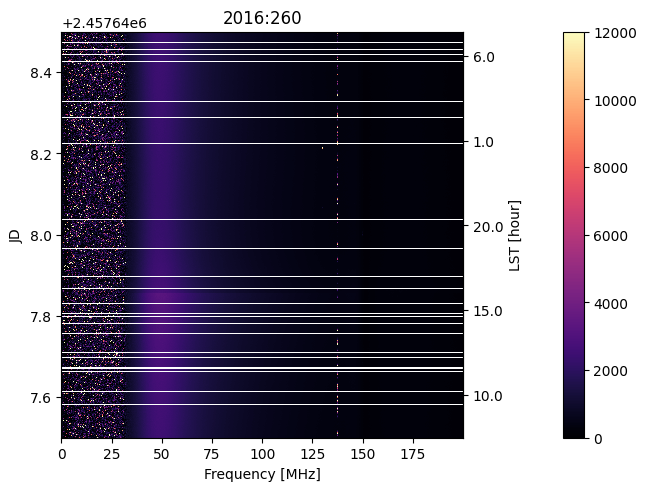

In [29]:
plots.plot_waterfall(data, vmin= 0, vmax=1.2e4);

In [30]:
# Get the number of flags in Alan's file for each filter
tf_alan = time_flags_alan[alan_gha_mask]

aux_mask = tf_alan['adc0'].astype(bool) & tf_alan['adc1'].astype(bool) & tf_alan['adc2'].astype(bool)
alan_flags = {
    'aux': ~aux_mask,
    'power_percent': tf_alan['ppercent'][aux_mask] <= 0,
    'peak_orbcomm': tf_alan['pkpower'][aux_mask] <= 0,
    'maxfm': tf_alan['fmpwr'][aux_mask] <= 0,
    'rmsf': tf_alan['rmsf'][aux_mask] <= 0,
}

In [31]:
table = []
for name, flg in data.flags.items():
    key = name.replace("_filter", "")
    ea_flags = flg.full_rank_flags[0,0,:,0]
    
    entry = {
        'name': key, 
        '# flags': np.sum(ea_flags), 
        '# flags (C)': np.sum(alan_flags[key]),
        '# differing flags': np.sum(ea_flags[aux_mask] ^ alan_flags[key]) if key!='aux' else np.sum(ea_flags ^ alan_flags[key]),
        "% flagged": 100*np.sum(flg.full_rank_flags[0,0,:,0])/flg.full_rank_flags.shape[2]
    }
    table.append(entry)
    
ea_complete = data.complete_flags[0,0,:, 0]
ccode_complete = np.any([tf_alan[key] <= 0 for key in ['ppercent', 'pkpower', 'd150', 'dloadmax', 'rmsf', 'fmpwr']], axis=0)

table.append({
    "name": "TOTAL (w/ overlapping)", 
    "# flags": np.sum(ea_complete), 
    "% flagged": 100*np.sum(ea_complete)/data.ntimes,
    "# flags (C)": np.sum(ccode_complete),
    "# differing flags": np.sum(ea_complete ^ ccode_complete),
    })
table = pd.DataFrame(table)
table = table.set_index('name')

def highlight_differing(s):
    return np.where(s > 0, 'background-color:orange;', 'background-color:green;')

slice_ = ["# differing flags"]
table.style.apply(highlight_differing, axis=0, subset=slice_)

,# flags,# flags (C),# differing flags,% flagged
name,,,,
aux,8,8,0,0.707965
power_percent,6,3,0,0.530973
peak_orbcomm,0,0,0,0.000000
maxfm,48,48,0,4.247788
rmsf,0,0,0,0.000000
TOTAL (w/ overlapping),59,59,0,5.221239


In [32]:
# Actually create an error if the total differing flags is non-zero
assert table.loc['TOTAL (w/ overlapping)']['# differing flags']==0

In [33]:
# Exit early if there's no data left.
if np.sum(~data.complete_flags)==0:
    sys.exit(0)

In [34]:
# Save the flags
np.savez(cache / f"{obsname}.integration-flags.npz", **{name: data.flags[name].flags for name in data.flags})

### Average Over LSTs

In [35]:
lstbin_data = lst_bin(data, **lstbin_params)

/data4/smurray/edges/edges-analysis/src/edges_analysis/averaging/averaging.py:573: RuntimeWarning: invalid value encountered in multiply
  sm = np.nansum(data * weights, axis=axis)
/data4/smurray/edges/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/data4/smurray/edges/pygsdata/src/pygsdata/register.py:25: UserWarning: Auxiliary measurements cannot being binned!
  newdata = self.func(data, *args, **kw)


In [36]:
data = select_freqs(lstbin_data, freq_range=[first_freqcut_min*un.MHz, first_freqcut_max*un.MHz])
pre_rfi_data = deepcopy(data)

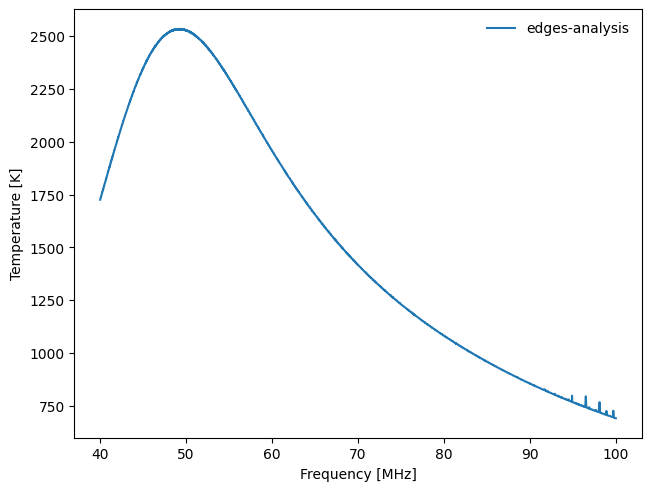

In [37]:
plot_single_spectrum(data)

## Single-LST-Bin Workflow

### RFI Excision

In [38]:
pre_rfi_file = (cache/ obsname).with_suffix('.pre-rfi.gsh5')
try:
    pre_rfi_data.write_gsh5(pre_rfi_file);
except NameError:
    pre_rfi_data = GSData.from_file(pre_rfi_file)

In [39]:
alan_rfi_flags = ~np.genfromtxt(alan_output_dir/"rfi_flags.txt").astype(bool)

In [40]:
if inject_flags:
    rfiflg = GSFlag(alan_rfi_flags[-1], axes=('freq',))
    data = pre_rfi_data.add_flags('injected-rfi', rfiflg, append_to_file=False)
else:
    data = filters.rfi_model_nonlinear_window_filter(
        pre_rfi_data,
        max_iter=100,
        model = mdl.Fourier(n_terms=37, period=1.5, transform=mdl.ZerotooneTransform(
            range=(
                data.freqs.min().to_value("MHz"), 
                data.freqs.max().to_value("MHz"),
            )
        )),
        fit_kwargs = {"method": 'alan-qrd'},
        window_frac = 16,
        min_window_size = 10,
        threshold = 2.5,
        reflag_thresh = 1.0,
        watershed = {
            1.0: 4,
            10.0: 8,
            100.0: 16
        }
    )

In [41]:
print(f"{data.complete_flags.sum()}/{data.nfreqs} channels flagged during xrfi")

1205/9831 channels flagged during xrfi


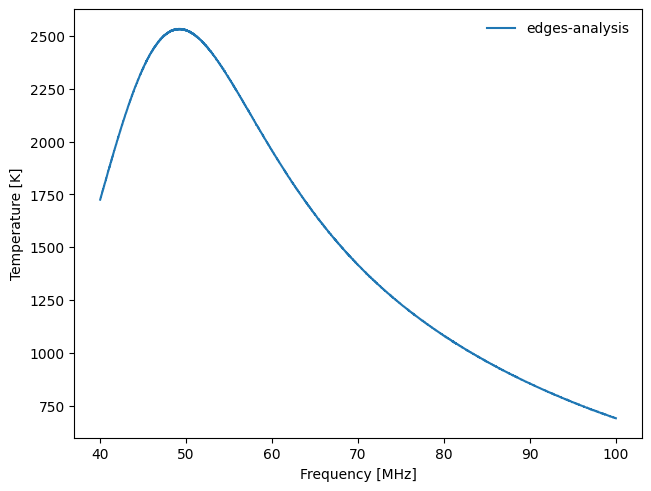

In [42]:
plot_single_spectrum(data)

### Smooth Over Frequency

In [43]:
pre_smooth_data = deepcopy(data)

In [44]:
data = gauss_smooth(data, **gauss_smooth_params)

In [45]:
# After smoothing, any flags over the frequency axis are removed, but nsamples is maintained correctly.
ourflags = data.nsamples[0,0,0] == 0

In [46]:
pre_cal_data = deepcopy(data)

In [47]:
alan_avg, n = read_spec_txt(alan_output_dir/"spegva.txt")

In [48]:
assert np.sum(~ourflags ^ (alan_avg['weight']>0))==0

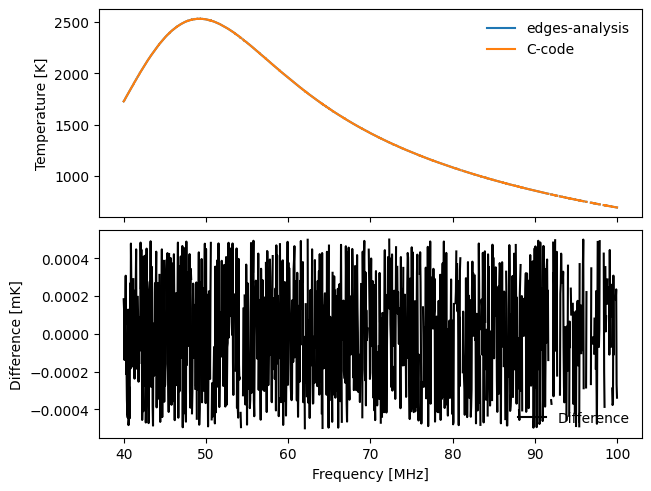

In [49]:
plot_single_spectrum(pre_cal_data, alan_avg['spectra'])

In [51]:
cache / f"{obsname}.averaged.gsh5"

PosixPath('cache/2016-260.averaged.gsh5')

In [50]:
pre_cal_data.write_gsh5(cache/f"{obsname}.averaged.gsh5");

GSData(telescope=Telescope(name='edges-low-alan', location=<EarthLocation (-2544175.08852437, 5102825.79106231, -2848558.83597113) m>, pols=('XX',), integration_time=<Quantity 13. s>, x_orientation=<Angle 0. deg>), data=array([[[[1727.37441618, 1731.92709813, 1739.82445086, ...,
           693.09116224,  692.46286173,  691.73188066]]]]), freqs=<Quantity [40.00244141, 40.05126953, 40.10009766, ..., 99.86572266,
           99.91455078, 99.96337891] MHz>, times=<Time object: scale='utc' format='yday' value=[['2016:259:22:18:27.780']]>, pols=('XX',), _effective_integration_time=<Quantity 13. s>, nsamples=array([[[[5106.06466176, 9085.21083305, 9141.12403983, ...,
          9141.0414237 , 9141.0414237 , 8887.98462205]]]]), loads=('ant',), flags={'empty_lsts': GSFlag(flags=array([False]), axes=('time',), history=!!python/tuple []
, filename=None)}, history=!!python/tuple
- function: select_lsts
  message: ''
  parameters:
    gha: true
    load: all
    lst_range:
    - 6.0
    - 18.0
  time